In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
import numpy as np, re, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader


In [2]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/*.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset>
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-30T...
    latitude           float64 ...
    longitude          float64 ...
    station_latitude   (station) float64 ...
    station_longitude  (station) float64 ...
Data variables: (12/14)
    u10                (station, valid_time) float32 ...
    v10                (station, valid_time) float32 ...
    d2m                (station, valid_time) float32 ...
    t2m                (station, valid_time) float32 ...
    msl                (station, valid_time) float32 ...
    sst                (station, valid_time) float32 ...
    ...                 ...
    mwd                (station, valid_time) float32 ...
    mwp                (station, valid_time) float32 ...
    swh                (station, valid_

In [3]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")
ds_sealevel = ds

In [4]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# assume your dataset is ds
# pick one station to demonstrate
station_id = 125  # example
residual = ds.residual.sel(station=station_id).to_pandas()

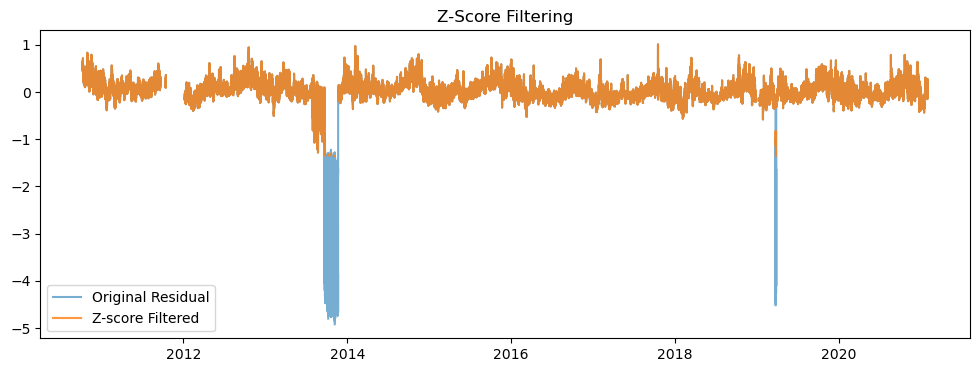

In [5]:
# Z-score threshold
z_thresh = 3

z_scores = (residual - residual.mean()) / residual.std()
residual_z_filtered = residual.where(np.abs(z_scores) < z_thresh)

plt.figure(figsize=(12,4))
plt.plot(residual, label="Original Residual", alpha=0.6)
plt.plot(residual_z_filtered, label="Z-score Filtered", alpha=0.8)
plt.legend(); plt.title("Z-Score Filtering")
plt.show()

In [28]:
ds = ds_sealevel

In [29]:
import xarray as xr
import numpy as np

# keep original untouched
ds["original"] = ds["residual"].astype("float64")

# --- Compute station-wise mean and std ---
mu  = ds["original"].mean(dim="valid_time", skipna=True)
sig = ds["original"].std(dim="valid_time", skipna=True)

# --- Build mask using Z-score ---
z_thresh = 5
z_scores = (ds["original"] - mu) / sig
mask = np.abs(z_scores) < z_thresh   # True = keep, False = set to NaN

# --- Apply Z-score filter ---
resid_filt = ds["original"].where(mask)

# --- Clause: negatives cannot exceed positives in magnitude ---
# compute max positive per station
max_pos = resid_filt.where(resid_filt > 0).max(dim="valid_time", skipna=True)

# build a mask: keep only if residual >= -max_pos
mask_balance = resid_filt >= (-max_pos)

# apply mask (bad negatives -> NaN)
resid_filt2 = resid_filt.where(mask_balance)

# assign back
ds["residual_filtered"] = resid_filt2

# --- Verify ---
print("Original count:", np.isfinite(ds["original"]).sum().item())
print("Filtered count:", np.isfinite(ds["residual_filtered"]).sum().item())
print("NaNs introduced:", np.isnan(ds["residual_filtered"]).sum().item())


Original count: 41149318
Filtered count: 41061545
NaNs introduced: 93973015


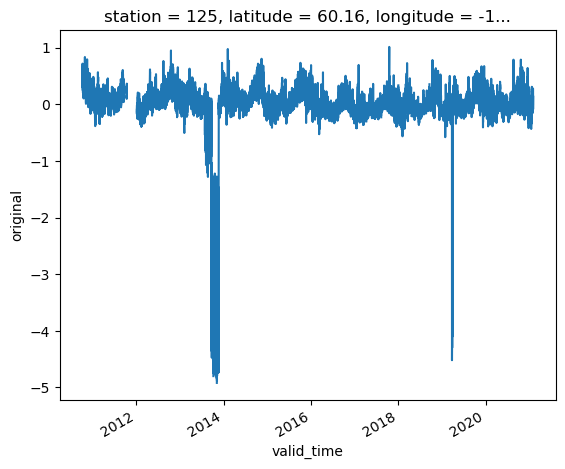

In [18]:
ds.sel(station=125).original.plot()

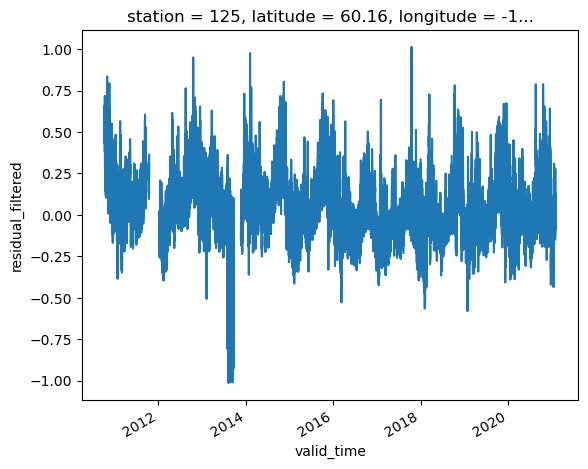

In [30]:
ds.sel(station=125).residual_filtered.plot()

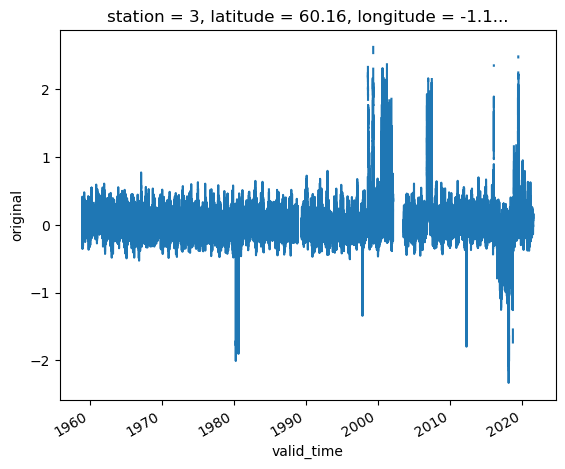

In [31]:
ds.sel(station=3).original.plot()

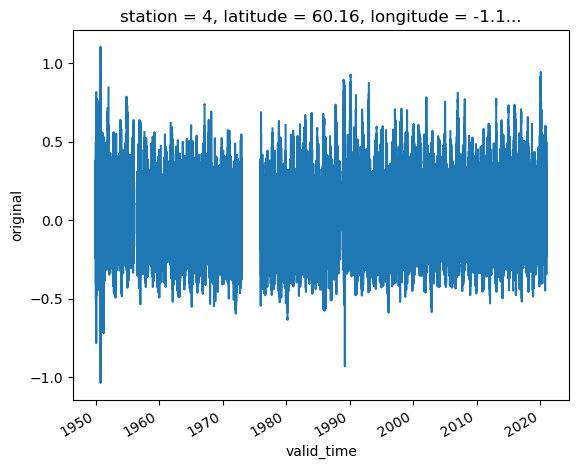

In [32]:
ds.sel(station=4).original.plot()

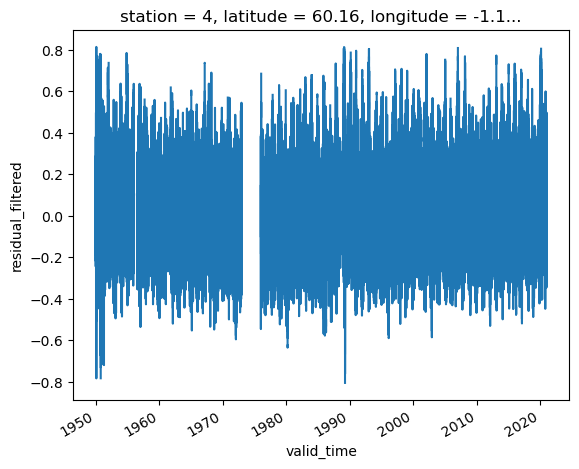

In [33]:
ds.sel(station=4).residual_filtered.plot()

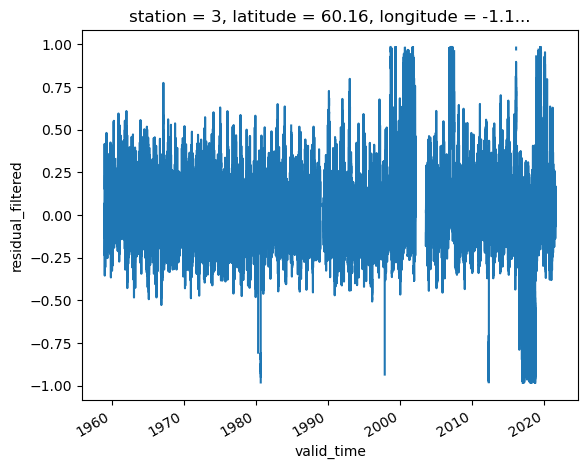

In [34]:
ds.sel(station=3).residual_filtered.plot()


In [12]:
# rolling mean ± k * rolling std
window = 48   # 2 days if hourly
k = 3

rolling_mean = residual.rolling(window=window, min_periods=1).mean()
rolling_std = residual.rolling(window=window, min_periods=1).std()

mask = (residual > rolling_mean - k*rolling_std) & (residual < rolling_mean + k*rolling_std)
residual_roll_filtered = residual.where(mask)


# try rolling mean

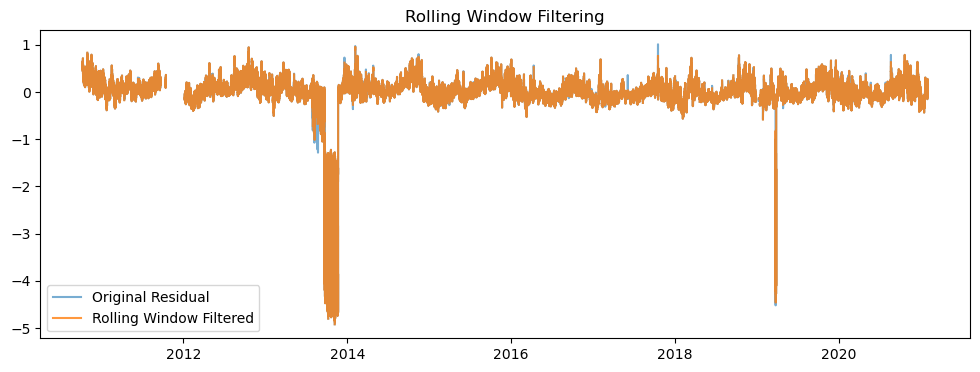

In [13]:
# rolling mean ± k * rolling std
window = 48  # 2 days if hourly
k = 3

rolling_mean = residual.rolling(window=window, min_periods=1).mean()
rolling_std = residual.rolling(window=window, min_periods=1).std()

mask = (residual > rolling_mean - k*rolling_std) & (residual < rolling_mean + k*rolling_std)
residual_roll_filtered = residual.where(mask)
plt.figure(figsize=(12,4))
plt.plot(residual, label="Original Residual", alpha=0.6)
plt.plot(residual_roll_filtered, label="Rolling Window Filtered", alpha=0.8)
plt.legend(); plt.title("Rolling Window Filtering")
plt.show()

In [14]:
z-score filter the dataset

SyntaxError: invalid syntax (3613639011.py, line 1)